# Filtering and trimming messages

## Review

Now, we have a deeper understanding of a few things:

- How to customize the graph state schema
- How to define custom state reducers
- How to use multiple graph state schemas

## Goals

Now, we can start using these concepts with models in LangGraph!

In the next few sessions, we'll build towards a chatbot that has long-term memory.

Because our chatbot will use messages, let's first talk a bit more about advanced ways to work with messages in graph state.

In [1]:
import dotenv

dotenv.load_dotenv()

True

## Messages as state

First, let's define some messages.

In [2]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = []

messages.append(AIMessage(f"So you said you were researching ocean mammals?", name="Bot"))
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Dibyajyoti"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Dibyajyoti

Yes, I know about whales. But what others should I learn about?


In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
llm.invoke(messages)

AIMessage(content='That\'s a great starting point! Whales are fascinating. To expand your knowledge of ocean mammals, you should definitely dive into learning about:\n\n**1. Dolphins:**\n*   **Diversity:** There are many different species of dolphins, from the common bottlenose dolphin to the highly intelligent orca (killer whale, which is actually the largest dolphin!).\n*   **Echolocation:** Their incredible ability to "see" with sound is a marvel of nature.\n*   **Social Behavior:** Dolphins are known for their complex social structures, communication, and playful nature.\n*   **Conservation:** Many dolphin populations face threats, so understanding their conservation status is important.\n\n**2. Porpoises:**\n*   **Distinction from Dolphins:** While often confused, porpoises are distinct. They have spade-shaped teeth (instead of conical), a blunter snout, and a more triangular dorsal fin.\n*   **Smaller Size:** Generally, porpoises are smaller than most dolphin species.\n*   **Habi

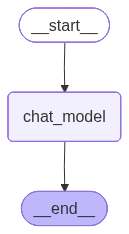

In [4]:
from IPython.display import Image, display
from langgraph.graph import MessagesState, StateGraph, START, END

# Node
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build graph
builder = StateGraph(MessagesState)

builder.add_node("chat_model", chat_model_node)

builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
output = graph.invoke({'messages': messages})

for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Dibyajyoti

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's fantastic that you're diving into the world of ocean mammals beyond whales! Whales are incredible, but there's a whole other fascinating group you should definitely explore: **pinnipeds**.

Pinnipeds are marine mammals that have flippers instead of feet. They are semi-aquatic, meaning they spend a significant amount of time in the water hunting for food, but they also come ashore to rest, breed, and molt.

There are three main groups of pinnipeds:

1.  **Seals (Phocidae):** These are the "true seals."
    *   **Key Characteristics:** They have no external ear flaps, and their hind flippers are not use

## Reducer

A practical challenge when working with messages is managing long-running conversations.

**Long-running conversations** result in **high token usage and latency** if we are not careful, because we pass a growing list of messages to the model.

We have a few ways to address this.

First, recall the trick we saw using `RemoveMessage` and the `add_messages` reducer.

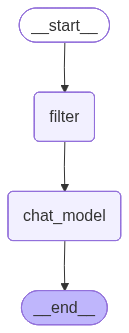

In [6]:
from IPython.display import Image, display
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_core.messages import RemoveMessage

# Nodes
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):    
    return {"messages": [llm.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)

builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)

builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
# Message list with a preamble
messages = []

messages.append(AIMessage("Hi.", name="Bot", id="1"))
messages.append(HumanMessage("Hi.", name="Dibyajyoti", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

# Invoke
output = graph.invoke({'messages': messages})

for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's a great starting point! Whales are fascinating. Since you're interested in ocean mammals beyond whales, you're in for a treat because there's a whole diverse group to explore. Here are some other key categories and examples of ocean mammals you should definitely learn about:

**1. Dolphins:**

*   **What to learn:** Dolphins are closely related to whales (they are all toothed whales, in fact!). They are known for their intelligence, complex social structures, and playful behavior.
*   **Examples:**
    *   **Bottlenose Dolphin:** The most common and recognizable species, often seen in aquariums and in the 

## Filtering messages

If you don't need or want to modify the graph state, you can just filter the messages you pass to the chat model.

For example, just pass in a filtered list: `llm.invoke(messages[-1:])` to the model.

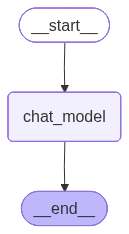

In [8]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"][-1:])]}

# Build graph
builder = StateGraph(MessagesState)

builder.add_node("chat_model", chat_model_node)

builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Narwhals!", name="Dibyajyoti"))

In [10]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Dibyajyoti

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's a great starting point! Whales are fascinating. Since you're interested in ocean mammals beyond whales, you're in for a treat because there's a whole diverse group to explore. Here are some other key categories and examples of ocean mammals you should definitely learn about:

**1. Dolphins:**

*   **What to learn:** Dolphins are closely related to whales (they are all toothed whales, in fact!). They are known f

In [11]:
# Invoke, using message filtering
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Dibyajyoti

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's a great starting point! Whales are fascinating. Since you're interested in ocean mammals beyond whales, you're in for a treat because there's a whole diverse group to explore. Here are some other key categories and examples of ocean mammals you should definitely learn about:

**1. Dolphins:**

*   **What to learn:** Dolphins are closely related to whales (they are all toothed whales, in fact!). They are known f

## Trim messages

Another approach is to [trim messages](https://docs.langchain.com/oss/python/langgraph/add-memory#trim-messages), based upon a set number of tokens.

This restricts the message history to a specified number of tokens. 

While filtering only returns a post-hoc subset of the messages between agents, trimming restricts the number of tokens that a chat model can use to respond.

See the trim_messages below.

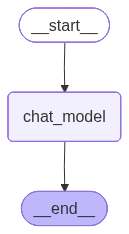

In [12]:
from langchain_core.messages import trim_messages
from langchain_google_genai import ChatGoogleGenerativeAI

# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens=100,
            strategy="last",
            token_counter=ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite"),
            allow_partial=False,
        )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)

builder.add_node("chat_model", chat_model_node)

builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Dibyajyoti"))

In [14]:
# Example of trimming messages
trim_messages(
    messages,
    max_tokens=100,
    strategy="last",
    token_counter=ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite"),
    allow_partial=True
)

[AIMessage(content='*   They are related to beluga whales.\n*   Narwhals are one of the few whale species that do not have teeth in the traditional sense for chewing.\n\nNarwhals are truly remarkable animals, perfectly adapted to their extreme environment. Their continued survival is dependent on our efforts to address the threats they face, particularly climate change and pollution. They remain a powerful symbol of the wild and untamed beauty of the Arctic.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dc4e2-ba5f-7a83-bf9a-c8ce33f87368-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 946, 'total_tokens': 955, 'input_token_details': {'cache_read': 0}}),
 HumanMessage(content='Tell me where Orcas live!', additional_kwargs={}, response_metadata={}, name='Dibyajyoti')]

In [15]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

In [16]:
for m in messages_out_trim['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Dibyajyoti

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's a great starting point! Whales are fascinating. Since you're interested in ocean mammals beyond whales, you're in for a treat because there's a whole diverse group to explore. Here are some other key categories and examples of ocean mammals you should definitely learn about:

**1. Dolphins:**

*   **What to learn:** Dolphins are closely related to whales (they are all toothed whales, in fact!). They are known f